In [2]:
import pandas as pd

df = pd.read_csv(r'C:\Users\User\Desktop\Data\Project\Amazon sales 2025\data/amazon_sales_data 2025.csv')
df.head()

,Order ID,Date,Product,Category,Price,Quantity,Total Sales,Customer Name,Customer Location,Payment Method,Status
0,ORD0001,14-03-25,Running Shoes,Footwear,60,3,180,Emma Clark,New York,Debit Card,Cancelled
1,ORD0002,20-03-25,Headphones,Electronics,100,4,400,Emily Johnson,San Francisco,Debit Card,Pending
2,ORD0003,15-02-25,Running Shoes,Footwear,60,2,120,John Doe,Denver,Amazon Pay,Cancelled
3,ORD0004,19-02-25,Running Shoes,Footwear,60,3,180,Olivia Wilson,Dallas,Credit Card,Pending
4,ORD0005,10-03-25,Smartwatch,Electronics,150,3,450,Emma Clark,New York,Debit Card,Pending


In [4]:
df.dtypes
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [8]:
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Total Sales'] = pd.to_numeric(df['Total Sales'], errors='coerce')
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y', errors='coerce')
df = df.drop_duplicates().dropna()


In [10]:
df.to_excel(r'C:\Users\User\Desktop\Data\Project\Amazon sales 2025\data/amazon_sales2025_clean.xlsx', index=False)

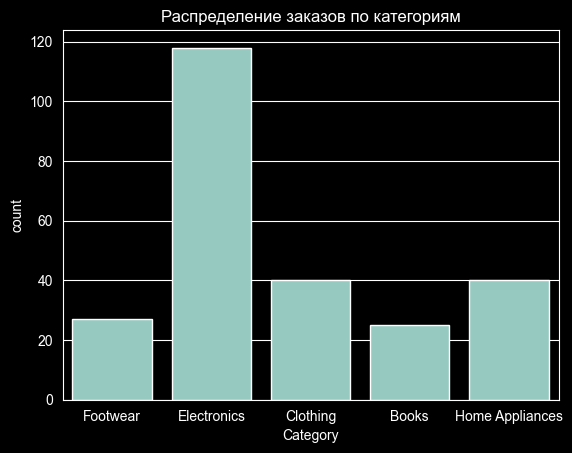

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Category')
plt.title('Распределение заказов по категориям')
plt.show()

In [16]:
df['Total Sales'].dtype
df['Total Sales'].head(10)
df['Month'] = df['Month'].astype(str)

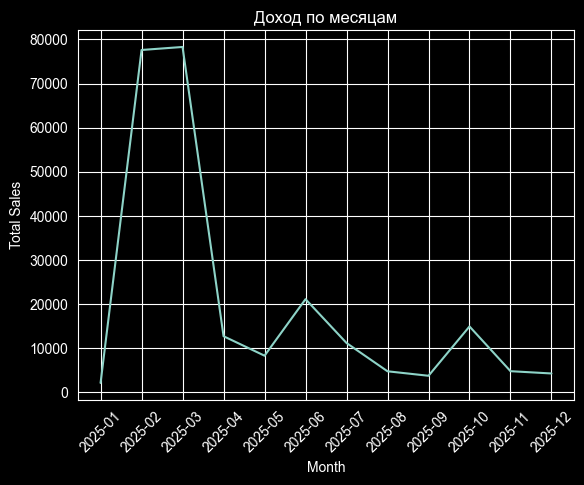

In [17]:
monthly_sales = df.groupby('Month')['Total Sales'].sum().reset_index()

import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=monthly_sales, x='Month', y='Total Sales')
plt.xticks(rotation=45)  # чтобы даты не накладывались
plt.title('Доход по месяцам')
plt.show()

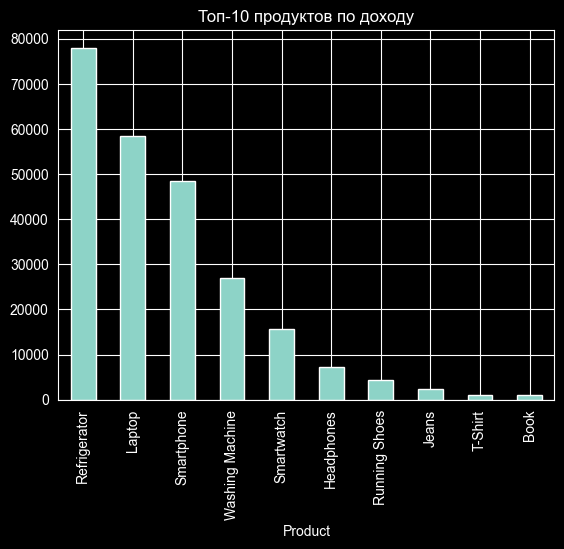

In [18]:
top_products = df.groupby('Product')['Total Sales'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='bar', title='Топ-10 продуктов по доходу')
plt.show()